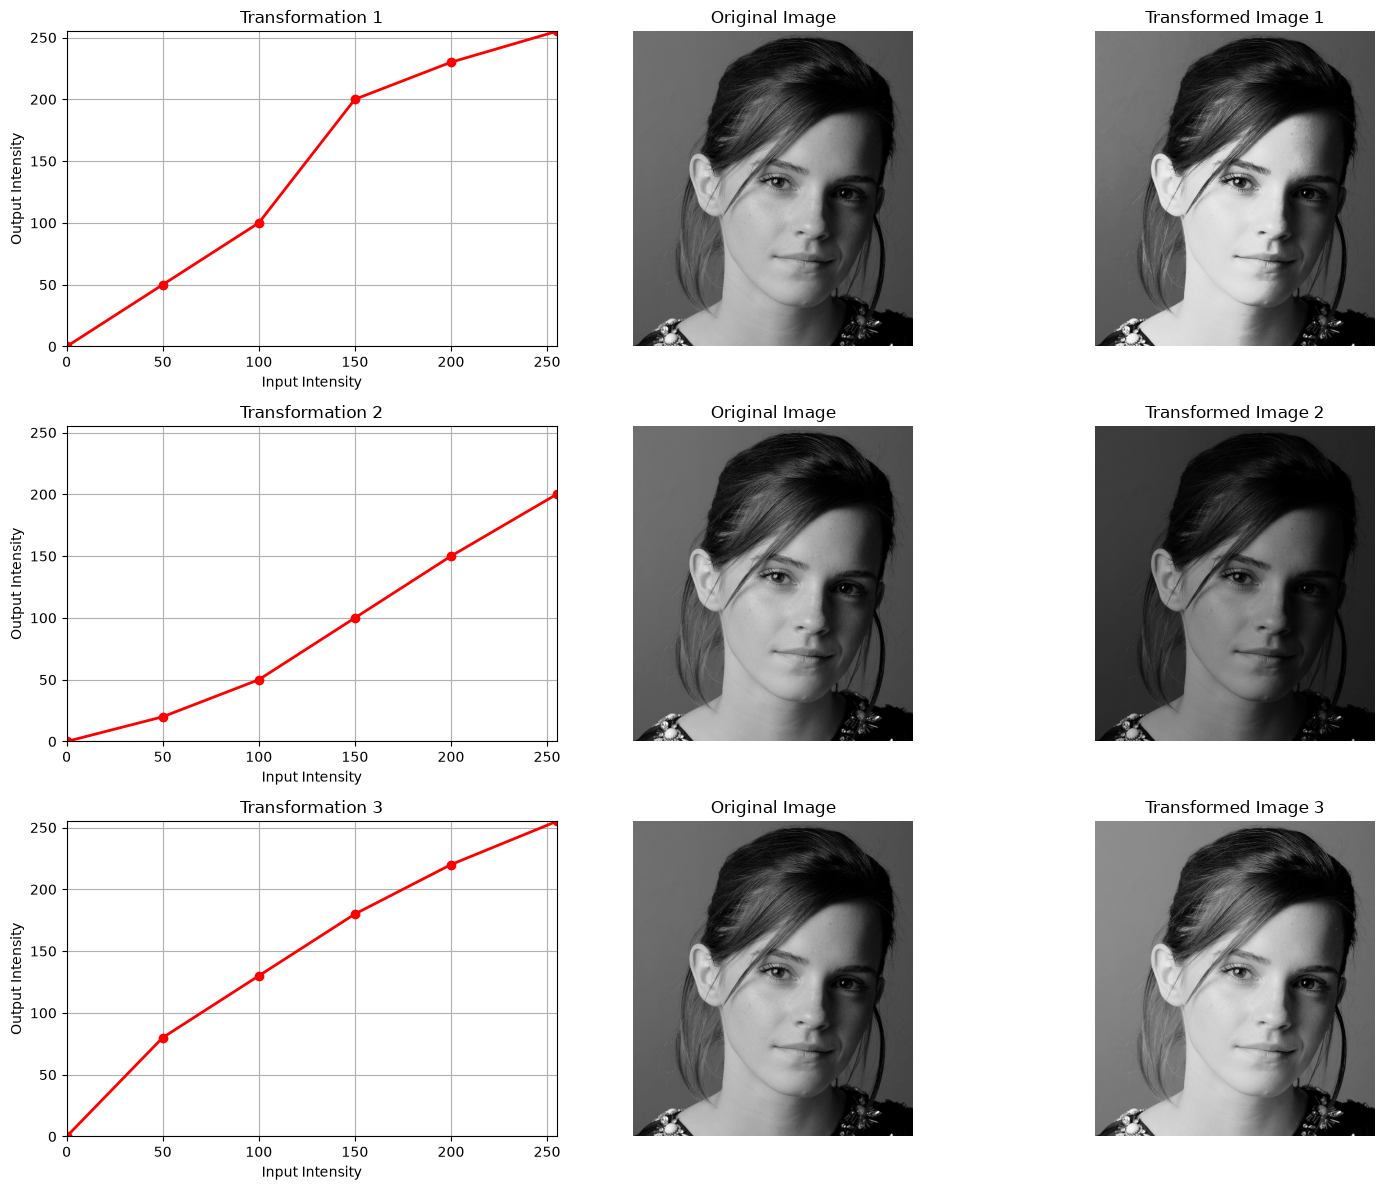

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def intensity_transform(im: np.ndarray, breakpoints: list) -> np.ndarray:
    bp = np.array(breakpoints, dtype=np.float32)
    x_in = np.arange(256)
    lut = np.interp(x_in, bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv.LUT(im, lut)


# Load image
img = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)


# Three different breakpoint sets
breakpoints_list = [
    [
        [0, 0],
        [50, 50],
        [100, 100],
        [150, 200],
        [200, 230],
        [255, 255]
    ],

    [
        [0, 0],
        [50, 20],
        [100, 50],
        [150, 100],
        [200, 150],
        [255, 200]
    ],

    [
        [0, 0],
        [50, 80],
        [100, 130],
        [150, 180],
        [200, 220],
        [255, 255]
    ]
]


# 3 rows × 3 columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))


for row, breakpoints in enumerate(breakpoints_list):

    # Apply transformation
    transformed_img = intensity_transform(img, breakpoints)

    bp = np.array(breakpoints)

    # --------------------------------
    # Column 1: Transformation curve
    # --------------------------------
    axes[row, 0].plot(
        bp[:, 0],
        bp[:, 1],
        'r-o',
        linewidth=2
    )

    axes[row, 0].set_title(
        f'Transformation {row + 1}'
    )

    axes[row, 0].set_xlabel('Input Intensity')
    axes[row, 0].set_ylabel('Output Intensity')
    axes[row, 0].set_xlim([0, 255])
    axes[row, 0].set_ylim([0, 255])
    axes[row, 0].grid(True)

    # --------------------------------
    # Column 2: Original image
    # --------------------------------
    axes[row, 1].imshow(
        img,
        cmap='gray',
        vmin=0,
        vmax=255
    )

    axes[row, 1].set_title('Original Image')
    axes[row, 1].axis('off')

    # --------------------------------
    # Column 3: Transformed image
    # --------------------------------
    axes[row, 2].imshow(
        transformed_img,
        cmap='gray',
        vmin=0,
        vmax=255
    )

    axes[row, 2].set_title(
        f'Transformed Image {row + 1}'
    )

    axes[row, 2].axis('off')


plt.tight_layout()
plt.show()